<a href="https://colab.research.google.com/github/volodymyr-fedorenko-nure/mtaad-fedorenko-ipzm-25-2/blob/main/Lab1_Intro_NumPy_Pandas_sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 1 — Дослідження даних з NumPy, Pandas та scikit-learn

**Набір даних:** `kc_house_data.csv`  
**Дозволені бібліотеки:** NumPy, Pandas, Matplotlib, scikit-learn (усі модулі)

## Налаштування — встановлення залежностей та імпорт

Запустіть комірку нижче один раз, щоб переконатись, що всі необхідні пакети встановлені.

In [1]:
# Встановлення залежностей (можна запускати повторно)
import sys
!{sys.executable} -m pip install numpy pandas matplotlib scikit-learn --quiet


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)


---
## Завдання 1 — Розминка з NumPy

**а)** Створіть масив NumPy з 10 000 значень, що підпорядковані нормальному розподілу N(0, 1). Обчисліть середнє, стандартне відхилення, мінімум і максимум за допомогою функцій NumPy — **без Python-циклів**.

**б)** Підрахуйте, скільки значень виходять за межі ±2 стандартних відхилення, використовуючи логічну індексацію. Яка це відсоткова частка? Порівняйте з теоретичним значенням ≈4,55 %.

In [ ]:
# Завдання 1а — створіть масив і обчисліть статистику
np.random.seed(42)
data = np.random.randn(10000)

mean_val = np.mean(data)
std_val = np.std(data)
min_val = np.min(data)
max_val = np.max(data)

print(f"Середнє: {mean_val:.4f}")
print(f"Стандартне відхилення: {std_val:.4f}")
print(f"Мінімум: {min_val:.4f}")
print(f"Максимум: {max_val:.4f}")

Середнє: -0.0021
Стандартне відхилення: 1.0034
Мінімум: -3.9224
Максимум: 3.9262


In [ ]:
# Завдання 1б — підрахуйте викиди за допомогою логічної індексації
lower_bound = mean_val - 2 * std_val
upper_bound = mean_val + 2 * std_val

outliers = data[(data < lower_bound) | (data > upper_bound)]
outliers_count = len(outliers)
outliers_percentage = (outliers_count / len(data)) * 100

print(f"Кількість значень поза межами ±2 ст. відхилень: {outliers_count}")
print(f"Відсоткова частка: {outliers_percentage:.2f}%")

Кількість значень поза межами ±2 ст. відхилень: 462
Відсоткова частка: 4.62%


**Ваша відповідь (б):** Отримана відсоткова частка викидів становить 4.62%, що дуже близько до теоретичного значення 4.55% для нормального розподілу.

---
## Завдання 2 — Завантаження та огляд набору даних

Завантажте `kc_house_data.csv` у Pandas DataFrame та дайте відповідь на питання нижче, написавши код:

1. Скільки рядків і стовпців у наборі даних?
2. Які мінімум, максимум, середнє та медіана цін на будинки?
3. Скільки унікальних поштових індексів є у наборі даних? Який поштовий індекс має найбільше оголошень?

In [3]:
# Завантаження набору даних
sales = pd.read_csv('kc_house_data.csv')
sales.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
# 2-і) Скільки рядків і стовпців?
rows, cols = sales.shape
print(f"Кількість рядків: {rows}")
print(f"Кількість стовпців: {cols}")

Кількість рядків: 21613
Кількість стовпців: 21


In [ ]:
# 2-іі) Мінімум, максимум, середнє та медіана ціни
price_min = sales['price'].min()
price_max = sales['price'].max()
price_mean = sales['price'].mean()
price_median = sales['price'].median()

print(f"Мінімальна ціна: {price_min}")
print(f"Максимальна ціна: {price_max}")
print(f"Середня ціна: {price_mean:.2f}")
print(f"Медіана ціни: {price_median}")

Мінімальна ціна: 75000.0
Максимальна ціна: 7700000.0
Середня ціна: 540088.14
Медіана ціни: 450000.0


In [ ]:
# 2-ііі) Кількість унікальних поштових індексів; індекс з найбільшою кількістю оголошень
unique_zipcodes = sales['zipcode'].nunique()
top_zipcode = sales['zipcode'].value_counts().idxmax()
top_zipcode_count = sales['zipcode'].value_counts().max()

print(f"Кількість унікальних поштових індексів: {unique_zipcodes}")
print(f"Поштовий індекс з найбільшою кількістю оголошень: {top_zipcode} ({top_zipcode_count} оголошень)")

Кількість унікальних поштових індексів: 70
Поштовий індекс з найбільшою кількістю оголошень: 98103 (602 оголошень)


---
## Завдання 3 — Візуалізація даних

Створіть **два графіки поруч**:

- **Лівий:** гістограма `price` (50 інтервалів, логарифмічна шкала по осі X).
- **Правий:** діаграма розсіювання `sqft_living` vs `price`, де кольором точок позначено `bedrooms`. Додайте підписи осей і colorbar.

Одним реченням для кожного графіка опишіть, що ви спостерігаєте.

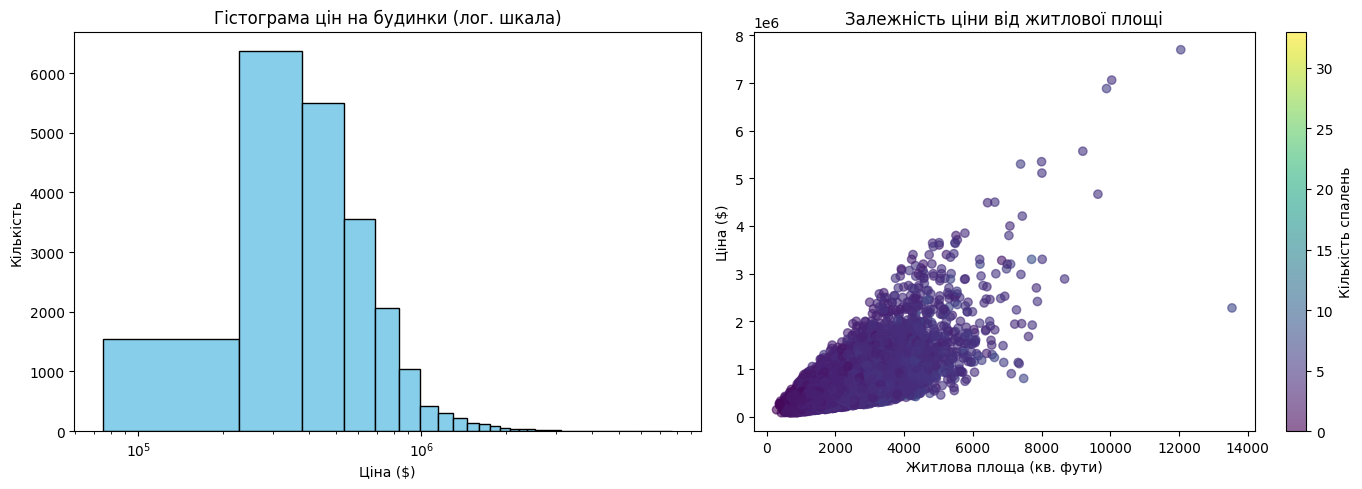

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Завдання 3 — лівий графік: гістограма ціни
axes[0].hist(sales['price'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xscale('log')
axes[0].set_title('Гістограма цін на будинки (лог. шкала)')
axes[0].set_xlabel('Ціна ($)')
axes[0].set_ylabel('Кількість')

# Завдання 3 — правий графік: діаграма розсіювання sqft_living vs price
scatter = axes[1].scatter(sales['sqft_living'], sales['price'],
                          c=sales['bedrooms'], cmap='viridis', alpha=0.6)
axes[1].set_title('Залежність ціни від житлової площі')
axes[1].set_xlabel('Житлова площа (кв. фути)')
axes[1].set_ylabel('Ціна ($)')

cbar = fig.colorbar(scatter, ax=axes[1])
cbar.set_label('Кількість спалень')

plt.tight_layout()
plt.show()


**Спостереження (лівий графік):** Розподіл цін на будинки є правобічно асиметричним, логарифмічна шкала показує, що більшість цін зосереджена в одному порядку величин (приблизно від 200 тис. до 1 млн), утворюючи дзвоноподібну форму.

**Спостереження (правий графік):** Існує чітка позитивна лінійна кореляція між житловою площею та ціною будинку; крім того, будинки з більшою площею, як правило, мають більше спалень.

---
## Завдання 4 — Навчання та оцінка регресійної моделі

Розбийте дані 80/20 (`random_state=42`). Навчіть `LinearRegression` з scikit-learn для передбачення `price` за єдиною ознакою `sqft_living`.

1. Вкажіть вільний член (intercept) та коефіцієнт для `sqft_living`.
2. Обчисліть MSE і RMSE на тестовій вибірці.
3. Яка передбачувана ціна будинку площею 2 500 кв. футів?

In [ ]:
# Поділ на навчальну та тестову вибірки
train_data, test_data = train_test_split(sales, test_size=0.2, random_state=42)


In [ ]:
# Завдання 4 — навчіть модель, вкажіть ваги, обчисліть MSE/RMSE, передбачте ціну для 2500 кв. фут.
X_train_1 = train_data[['sqft_living']]
y_train = train_data['price']
X_test_1 = test_data[['sqft_living']]
y_test = test_data['price']

model_1 = LinearRegression()
model_1.fit(X_train_1, y_train)

intercept = model_1.intercept_
coef = model_1.coef_[0]

print(f"1. Вільний член (intercept): {intercept:.2f}")
print(f"   Коефіцієнт (sqft_living): {coef:.2f}")

y_pred_1 = model_1.predict(X_test_1)
mse_1 = mean_squared_error(y_test, y_pred_1)
rmse_1 = np.sqrt(mse_1)

print(f"2. MSE на тестовій вибірці: {mse_1:.2f}")
print(f"   RMSE на тестовій вибірці: {rmse_1:.2f}")

house_2500 = pd.DataFrame({'sqft_living': [2500]})
price_2500 = model_1.predict(house_2500)[0]
print(f"3. Передбачувана ціна будинку площею 2 500 кв. футів: ${price_2500:.2f}")

1. Вільний член (intercept): -41999.19
   Коефіцієнт (sqft_living): 279.55
2. MSE на тестовій вибірці: 76484977061.78
   RMSE на тестовій вибірці: 276559.17
3. Передбачувана ціна будинку площею 2 500 кв. футів: $656887.76


---
## Завдання 5 — Порівняння двох моделей

Навчіть другу `LinearRegression` з ознаками: `sqft_living`, `bedrooms`, `bathrooms`, `yr_built`. Порівняйте RMSE на тестовій вибірці між Моделлю 1 та Моделлю 2. Яке значення нижче? Коротко поясніть чому.

In [ ]:
# Завдання 5 — модель з чотирма ознаками та порівняння RMSE
features = ['sqft_living', 'bedrooms', 'bathrooms', 'yr_built']

X_train_2 = train_data[features]
X_test_2 = test_data[features]

model_2 = LinearRegression()
model_2.fit(X_train_2, y_train)

y_pred_2 = model_2.predict(X_test_2)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred_2))

print(f"RMSE (Модель 1 - одна ознака): {rmse_1:.2f}")
print(f"RMSE (Модель 2 - чотири ознаки): {rmse_2:.2f}")

RMSE (Модель 1 - одна ознака): 276559.17
RMSE (Модель 2 - чотири ознаки): 262985.98


**Відповідь:** RMSE у Моделі 2 є нижчим. Це пояснюється тим, що друга модель враховує більше інформативних ознак (спальні, ванні кімнати, рік побудови), що дозволяє їй знаходити складніші залежності і точніше передбачати ціну, зменшуючи середню помилку.

---
## ✨ Бонус — Аналіз залишків

Для вашої кращої моделі обчисліть вектор залишків (predicted − actual). Побудуйте гістограму. Чи виглядають залишки нормально розподіленими та центрованими навколо нуля? Що означав би систематичний ненульовий середній залишок?

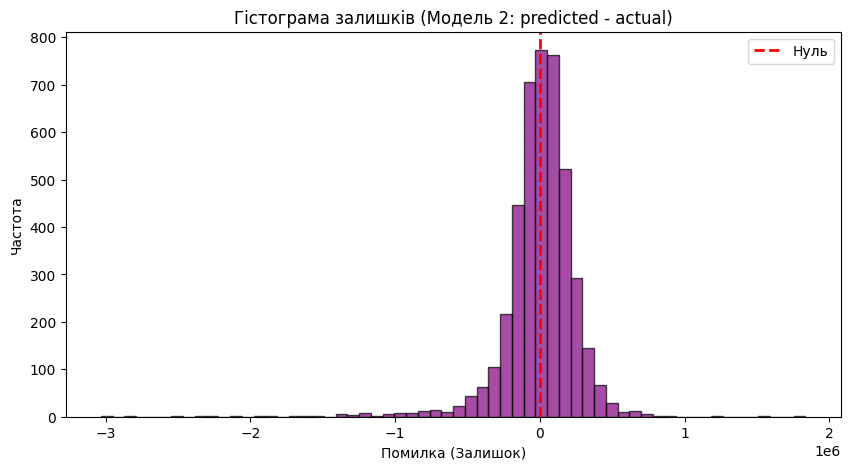

Середній залишок: -1611.51


In [ ]:
# Бонус — аналіз залишків
residuals = y_pred_2 - y_test

plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=60, color='purple', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Нуль')
plt.title('Гістограма залишків (Модель 2: predicted - actual)')
plt.xlabel('Помилка (Залишок)')
plt.ylabel('Частота')
plt.legend()
plt.show()

mean_residual = residuals.mean()
print(f"Середній залишок: {mean_residual:.2f}")

**Спостереження:**
Залишки виглядають приблизно нормально розподіленими та візуально центрованими навколо нуля.
Що означав би систематичний ненульовий середній залишок: це вказувало б на те, що модель має "зміщення". Наприклад, якщо середній залишок (predicted - actual) був би значно більшим за нуль, це б означало, що наша модель систематично переоцінює вартість будинків.